## 1. Preparação de Dados

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

pd.set_option('display.width', 140)
np.random.seed(42)

df = pd.read_parquet('../data.parquet')

indicadores = ['ceb_afd_4_1', 'ceb_afd_4_2', 'ceb_escolas_4_2', 'ceb_escolas_4_3', 'ceb_escolas_4_5']
sub = df[df['id_indicator'].isin(indicadores)]

# A base está em formato longo (indicador, município, valor) -> pivotar para formato largo
dados = sub.pivot(index='id_local', columns='id_indicator', values='value')[indicadores]
dados.index.name = 'municipio'

print(f"Municípios disponíveis na base: {dados.shape[0]}")
print("\nValores ausentes por indicador:")
print(dados.isna().sum())

Municípios disponíveis na base: 208

Valores ausentes por indicador:
id_indicator
ceb_afd_4_1        41
ceb_afd_4_2        26
ceb_escolas_4_2     0
ceb_escolas_4_3     0
ceb_escolas_4_5     0
dtype: int64


os indicadores ceb_afd_4_1 e ceb_afd_4_2 apresentam valores ausentes para alguns municipios como o isolation forest do sklearn não suporta NaN nos dados qualquer municipio que tenha valor ausente será dropado         

In [17]:
dados = dados.dropna()
print(f"Municípios com os 5 indicadores completos: {dados.shape[0]}")
dados.describe().round(3)

Municípios com os 5 indicadores completos: 163


id_indicator,ceb_afd_4_1,ceb_afd_4_2,ceb_escolas_4_2,ceb_escolas_4_3,ceb_escolas_4_5
count,163.000,163.000,163.000,163.000,163.000
mean,0.603,0.691,0.431,0.175,0.551
std,0.272,0.208,0.306,0.181,0.280
min,0.000,0.067,0.000,0.000,0.000
25%,0.400,0.531,0.179,0.000,0.375
50%,0.620,0.700,0.375,0.133,0.529
75%,0.846,0.857,0.681,0.250,0.750
max,1.000,1.000,1.000,0.769,1.000


# A)


In [18]:
X = dados[indicadores].values

resultados_sensibilidade = {}
for c in [0.02, 0.05, 0.10]:
    modelo = IsolationForest(n_estimators=200, contamination=c, random_state=42)
    labels = modelo.fit_predict(X)
    n_anomalos = int((labels == -1).sum())
    resultados_sensibilidade[c] = n_anomalos
    print(f"contamination = {c:.2f}  ->  {n_anomalos} municípios sinalizados como anômalos "
          f"({n_anomalos/len(X)*100:.1f}% de {len(X)})")

contamination = 0.02  ->  4 municípios sinalizados como anômalos (2.5% de 163)
contamination = 0.05  ->  9 municípios sinalizados como anômalos (5.5% de 163)
contamination = 0.10  ->  17 municípios sinalizados como anômalos (10.4% de 163)


**Interpretação da sensibilidade:**

| `contamination` | Municípios sinalizados | % da amostra |
|---|---|---|
| 0,02 | 4 | ~2,5% |
| 0,05 | 9 | ~5,5% |
| 0,10 | 17 | ~10,4% |

# B)

In [19]:
modelo_final = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
labels = modelo_final.fit_predict(X)

# decision_function: valores MAIORES = mais normal. Invertendo e normalizando para [0,1]
# obtemos um score onde valores PRÓXIMOS DE 1 = mais anômalo 
score_bruto = -modelo_final.decision_function(X)
score_normalizado = (score_bruto - score_bruto.min()) / (score_bruto.max() - score_bruto.min())

dados['score_anomalia'] = score_normalizado
dados['status'] = np.where(labels == -1, 'anômalo', 'normal')

print(dados['status'].value_counts())

status
normal     154
anômalo      9
Name: count, dtype: int64


In [20]:
municipios_anomalos = dados[dados['status'] == 'anômalo'].sort_values('score_anomalia', ascending=False)
municipios_anomalos.round(3)

id_indicator,ceb_afd_4_1,ceb_afd_4_2,ceb_escolas_4_2,ceb_escolas_4_3,ceb_escolas_4_5,score_anomalia,status
municipio,,,,,,,
2506103,0.400,0.222,0.077,0.769,0.077,1.000,anômalo
2500502,0.000,0.532,0.333,0.667,1.000,0.904,anômalo
2514602,0.000,1.000,0.000,0.000,0.000,0.890,anômalo
2513604,0.018,0.067,0.250,0.250,0.500,0.884,anômalo
2511905,0.000,0.990,0.667,0.500,0.833,0.828,anômalo
2508307,0.333,0.200,1.000,0.000,1.000,0.800,anômalo
2500536,0.308,0.333,0.000,0.500,0.000,0.788,anômalo
2512788,1.000,1.000,0.000,0.500,0.000,0.760,anômalo
2504504,0.000,1.000,0.500,0.000,1.000,0.707,anômalo


In [21]:
# Classificação de cada anomalia como "positiva" ou "negativa"
#
# Regra adotada:
#   - "positiva"  -> desempenho/infraestrutura muito acima do padrão nos 5 indicadores em conjunto:
#                    z-score médio > 0,5 (bem acima da média da amostra) E nenhum indicador
#                    isolado em nível crítico (valor mínimo entre os 5 >= 0,30).
#   - "negativa"  -> qualquer outro caso: ou o município está, em média, abaixo do padrão,
#                    ou apresenta uma combinação inconsistente (ex.: infraestrutura física boa,
#                    mas formação docente muito baixa) -- em ambos os casos, ao menos um dos
#                    cinco indicadores permanece em nível crítico, o que caracteriza um sinal
#                    de atenção mesmo quando outras dimensões estão acima da média.

medias = dados[indicadores].mean()
desvios = dados[indicadores].std()
z_scores = (dados[indicadores] - medias) / desvios

z_medio = z_scores.mean(axis=1)
valor_minimo = dados[indicadores].min(axis=1)

def classifica_anomalia(status, z_med, v_min):
    if status != 'anômalo':
        return None
    if (z_med > 0.5) and (v_min >= 0.30):
        return 'positiva'
    return 'negativa'

dados['tipo_anomalia'] = [
    classifica_anomalia(s, zm, vm)
    for s, zm, vm in zip(dados['status'], z_medio, valor_minimo)
]

tabela_final = dados.loc[dados['status'] == 'anômalo',
                          indicadores + ['score_anomalia', 'status', 'tipo_anomalia']]
tabela_final = tabela_final.sort_values('score_anomalia', ascending=False)
tabela_final.round(3)

id_indicator,ceb_afd_4_1,ceb_afd_4_2,ceb_escolas_4_2,ceb_escolas_4_3,ceb_escolas_4_5,score_anomalia,status,tipo_anomalia
municipio,,,,,,,,
2506103,0.400,0.222,0.077,0.769,0.077,1.000,anômalo,negativa
2500502,0.000,0.532,0.333,0.667,1.000,0.904,anômalo,negativa
2514602,0.000,1.000,0.000,0.000,0.000,0.890,anômalo,negativa
2513604,0.018,0.067,0.250,0.250,0.500,0.884,anômalo,negativa
2511905,0.000,0.990,0.667,0.500,0.833,0.828,anômalo,negativa
2508307,0.333,0.200,1.000,0.000,1.000,0.800,anômalo,negativa
2500536,0.308,0.333,0.000,0.500,0.000,0.788,anômalo,negativa
2512788,1.000,1.000,0.000,0.500,0.000,0.760,anômalo,negativa
2504504,0.000,1.000,0.500,0.000,1.000,0.707,anômalo,negativa


# C)

In [22]:
pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(X)

dados['PC1'] = componentes[:, 0]
dados['PC2'] = componentes[:, 1]

var_explicada = pca.explained_variance_ratio_
print(f"Variância explicada: PC1 = {var_explicada[0]*100:.1f}%, PC2 = {var_explicada[1]*100:.1f}%, "
      f"total = {var_explicada.sum()*100:.1f}%")

Variância explicada: PC1 = 33.0%, PC2 = 30.5%, total = 63.5%


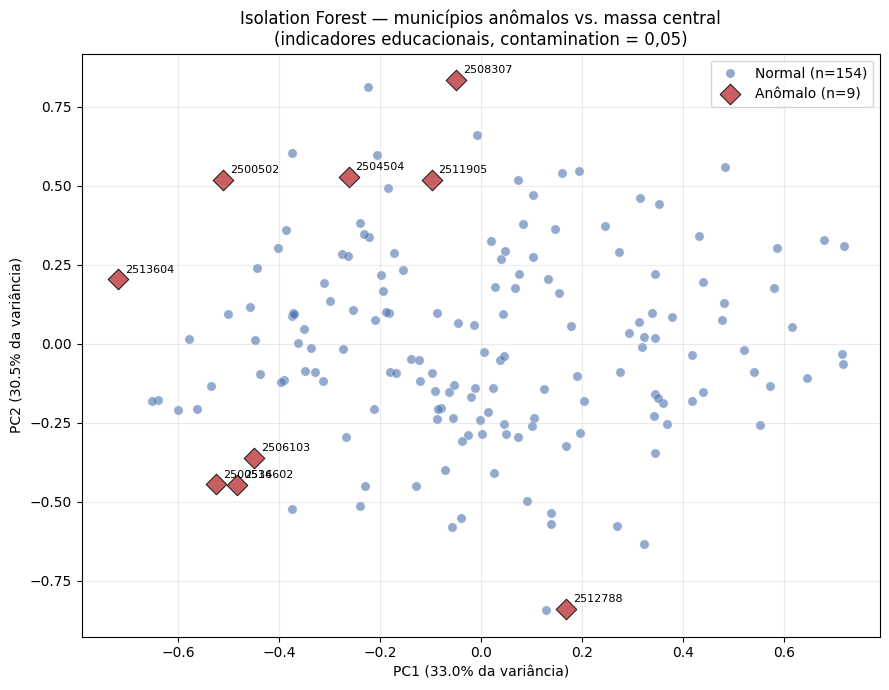

In [23]:
fig, ax = plt.subplots(figsize=(9, 7))

normais = dados[dados['status'] == 'normal']
anomalos = dados[dados['status'] == 'anômalo']

ax.scatter(normais['PC1'], normais['PC2'], c='#4C72B0', alpha=0.6, s=45,
           label=f'Normal (n={len(normais)})', edgecolor='white', linewidth=0.4)
ax.scatter(anomalos['PC1'], anomalos['PC2'], c='#C44E52', alpha=0.9, s=110,
           label=f'Anômalo (n={len(anomalos)})', edgecolor='black', linewidth=0.7, marker='D')

for idx, row in anomalos.iterrows():
    ax.annotate(str(idx), (row['PC1'], row['PC2']), fontsize=8, xytext=(5, 5),
                textcoords='offset points')

ax.set_xlabel(f'PC1 ({var_explicada[0]*100:.1f}% da variância)')
ax.set_ylabel(f'PC2 ({var_explicada[1]*100:.1f}% da variância)')
ax.set_title('Isolation Forest — municípios anômalos vs. massa central\n(indicadores educacionais, contamination = 0,05)')
ax.legend(loc='best')
ax.grid(alpha=0.25)
plt.tight_layout()
#plt.savefig('pca_anomalias.png', dpi=300)
plt.show()

O gráfico confirma que o Isolation Forest separa os municípios anômalos por afastamento da região de maior densidade de pontos, e não por qualquer regra fixa de distância a um centro geométrico. Os municípios classificados como "normal" formam um agrupamento relativamente compacto ao longo do plano PC1 x PC2, enquanto os nove municípios "anômalos" aparecem nas bordas dessa nuvem, em direções distintas entre si — não deslocados todos para um mesmo lado do gráfico, mas espalhados perifericamente em ângulos diferentes. Esse padrão é coerente com o princípio de isolamento discutido em aula: o algoritmo constrói as árvores a partir de cortes aleatórios sobre uma variável por vez, e um ponto é isolado com poucos cortes sempre que ocupa uma região de baixa densidade em pelo menos uma das dimensões originais, independentemente da direção desse afastamento. Por isso, anomalias "positivas" e "negativas" — ou, como observado nesta base, anomalias por precariedade generalizada e anomalias por combinação inconsistente entre indicadores — não precisam ocupar a mesma região do espaço de componentes principais; elas apenas precisam ser raras o suficiente em alguma combinação de variáveis para exigir poucos cortes até o isolamento.

A dispersão dos pontos anômalos ao redor de toda a periferia, e não concentrada em um único quadrante, também expõe uma limitação da projeção em duas dimensões: como PC1 e PC2 conjuntamente explicam apenas uma fração da variância original dos cinco indicadores, parte da distância que separa cada município anômalo da massa central foi construída em dimensões que a projeção não captura totalmente. Ainda assim, o fato de nenhum ponto anômalo aparecer imerso no núcleo denso do gráfico é suficiente para validar visualmente a coerência entre o rótulo atribuído pelo modelo e a posição relativa de cada município na estrutura geral dos dados, confirmando que a classificação obtida no Item B não é um artefato isolado do score numérico, mas corresponde a um afastamento real e identificável da distribuição conjunta dos indicadores educacionais.

In [27]:
dados.round(3)

id_indicator,ceb_afd_4_1,ceb_afd_4_2,ceb_escolas_4_2,ceb_escolas_4_3,ceb_escolas_4_5,score_anomalia,status,tipo_anomalia,PC1,PC2
municipio,,,,,,,,,,
2500106,0.524,0.856,0.706,0.588,0.176,0.573,normal,None,0.275,-0.090
2500304,0.625,0.415,0.514,0.086,0.514,0.158,normal,None,-0.045,0.064
2500403,0.634,0.636,0.056,0.000,0.222,0.242,normal,None,-0.230,-0.449
2500502,0.000,0.532,0.333,0.667,1.000,0.904,anômalo,negativa,-0.511,0.519
2500536,0.308,0.333,0.000,0.500,0.000,0.788,anômalo,negativa,-0.526,-0.446
...,...,...,...,...,...,...,...,...,...,...
2516607,0.478,0.602,0.111,0.333,0.556,0.167,normal,None,-0.314,-0.119
2516706,0.833,1.000,0.143,0.000,0.286,0.220,normal,None,0.090,-0.499
2516805,0.371,0.490,0.454,0.000,0.454,0.070,normal,None,-0.210,0.074


In [26]:
municipios_anomalos.round(3)

id_indicator,ceb_afd_4_1,ceb_afd_4_2,ceb_escolas_4_2,ceb_escolas_4_3,ceb_escolas_4_5,score_anomalia,status
municipio,,,,,,,
2506103,0.400,0.222,0.077,0.769,0.077,1.000,anômalo
2500502,0.000,0.532,0.333,0.667,1.000,0.904,anômalo
2514602,0.000,1.000,0.000,0.000,0.000,0.890,anômalo
2513604,0.018,0.067,0.250,0.250,0.500,0.884,anômalo
2511905,0.000,0.990,0.667,0.500,0.833,0.828,anômalo
2508307,0.333,0.200,1.000,0.000,1.000,0.800,anômalo
2500536,0.308,0.333,0.000,0.500,0.000,0.788,anômalo
2512788,1.000,1.000,0.000,0.500,0.000,0.760,anômalo
2504504,0.000,1.000,0.500,0.000,1.000,0.707,anômalo


# D)

Uma anomalia detectada pelo Isolation Forest não equivale, em si, a um problema educacional: ela indica apenas que a combinação dos cinco indicadores analisados — formação docente adequada na Educação Infantil (`ceb_afd_4_1`), formação docente adequada no Ensino Fundamental I (`ceb_afd_4_2`), percentual de escolas com internet para fins pedagógicos (`ceb_escolas_4_2`), presença de laboratório de informática (`ceb_escolas_4_3`) e percentual de escolas com água encanada (`ceb_escolas_4_5`) — se afasta do padrão predominante entre os municípios comparados. O algoritmo isola pela raridade estatística da combinação, não pela direção do desvio, e os resultados obtidos tornam esse ponto concreto. O município 2512788 atinge o valor máximo (1,0) em formação docente tanto na Educação Infantil quanto no Ensino Fundamental I, mas apresenta 0% de escolas com internet pedagógica e com água encanada; o município 2508307 tem a situação inversa, com 100% de escolas conectadas e com água encanada, porém formação docente baixa e nenhuma escola com laboratório de informática. Em ambos os casos, o município foi sinalizado não por estar "ruim" em bloco, mas por reunir simultaneamente um extremo de excelência em uma dimensão — formação de professores, no primeiro caso, infraestrutura física, no segundo — com uma carência igualmente extrema em outra. Isso evidencia que investimento em capital humano docente e investimento em infraestrutura física escolar podem caminhar de forma dissociada dentro de um mesmo município, um achado substantivo que só emerge porque o modelo avalia os cinco indicadores em conjunto, e não isoladamente. Ao lado desses casos de descompasso entre dimensões, há também municípios cuja anomalia é predominantemente negativa em bloco, como 2513604, com formação docente próxima de zero nos dois níveis e nenhum dos três indicadores de infraestrutura escolar acima de 50% — esse sim um padrão compatível com precariedade generalizada, e não com um trade-off entre eixos de investimento.

Essa distinção tem consequência direta sobre o uso dos resultados em auditoria automática. Tratar a lista de municípios sinalizados como uma lista de irregularidades a corrigir puniria, no caso de 2512788, exatamente o tipo de gestão que a política educacional deveria reconhecer como referência em qualificação docente, apenas porque a mesma gestão ainda não equacionou a infraestrutura física das escolas. Tratar a mesma lista como neutra, sem investigação qualitativa, ignoraria que casos como o de 2513604 refletem privação em múltiplas frentes ao mesmo tempo e demandam prioridade orçamentária imediata. Soma-se a isso o risco de os valores extremos observados (0% ou 100% simultâneos, como em 2514602 e 2504504) refletirem falha de preenchimento do indicador administrativo, e não a realidade da rede municipal — hipótese que nenhum score estatístico consegue descartar sozinho. A escolha do `contamination`, por sua vez, é uma decisão arbitrária de quantos municípios devem ser tratados como prioritários, não um critério técnico objetivo derivado dos dados; variar esse parâmetro de 0,02 para 0,10 mais que quadruplicou a lista de sinalizados na análise conduzida, o que mostra que a fronteira entre "atípico" e "dentro do esperado" é uma escolha do analista, e uma auditoria automática a herdaria como se fosse um fato dado. Por essas razões, o resultado do Isolation Forest deve funcionar como instrumento de triagem, direcionando um número gerenciável de municípios à checagem qualitativa dos dados e à visita técnica, e não como veredito substituto dessa etapa: a rotulagem estatística indica onde olhar, mas não dispensa a pergunta sobre por que aquele padrão se formou.